# Autor:
ROJAS MARTINEZ JONATHAN FRANCISCO

In [1]:
import pandas as pd
import numpy as np

In [10]:
# EScogemos solamente las columnas que vienen del documento para que se logre hacer la predicción correcta
# Importamos el archivo
try:
    df = pd.read_csv('vehiculos.csv')
except FileNotFoundError:
    print("Error: No se encontró el archivo")

print(df.columns)

Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr_axis_aspect_ratio', 'max_length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'pr_axis_rectangularity', 'max_length_rectangularity',
       'scaled_variance_major_axis', 'scaled_variance_minor_axis',
       'scaled_radius_gyration', 'skewness_major_axis', 'skewness_minor_axis',
       'kurtosis_minor_axis', 'kurtosis_major_axis', 'hollows_ratio',
       'vehicle_class'],
      dtype='str')


![Screenshot 2026-07-11 193144.png](<attachment:Screenshot 2026-07-11 193144.png>)

Columnas del word
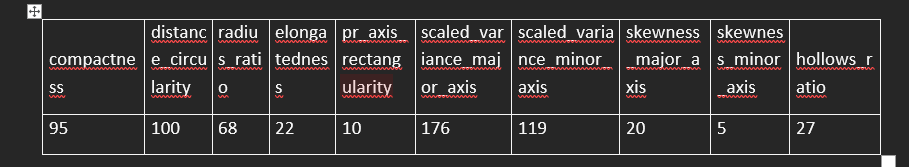

In [26]:
# Vemos las columnas y solo escogemos las que vienen del documento word
columnas_completas =df.columns
columnas_seleccionadas = ['compactness',	
                          'distance_circularity',
                          'radius_ratio','elongatedness',
                          'pr_axis_rectangularity',
                          'scaled_variance_major_axis',
                          'scaled_variance_minor_axis',
                          'skewness_major_axis',
                          'skewness_minor_axis',
                          'hollows_ratio',
                          'vehicle_class']
df_mod = df.copy()
df_mod = df_mod[columnas_seleccionadas]
print(df_mod.head())

   compactness  distance_circularity  radius_ratio  elongatedness  \
0         95.0                  83.0         178.0           42.0   
1         91.0                  84.0         141.0           45.0   
2        104.0                 106.0         209.0           32.0   
3         93.0                  82.0         159.0           46.0   
4         85.0                  70.0         205.0           45.0   

   pr_axis_rectangularity  scaled_variance_major_axis  \
0                    20.0                       176.0   
1                    19.0                       170.0   
2                    23.0                       223.0   
3                    19.0                       160.0   
4                    19.0                       241.0   

   scaled_variance_minor_axis  skewness_major_axis  skewness_minor_axis  \
0                       379.0                 70.0                  6.0   
1                       330.0                 72.0                  9.0   
2                

# Bosque aleatorio

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

def random_forest(df):
    print("--- Entrenando Modelo: Random Forest ---")

    # Separar características (X) y la clase a predecir (y)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    # Dividir los datos en entrenamiento y prueba (80% - 20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Escalar los datos (Estandarización)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Crear y entrenar el modelo
    modelo = RandomForestClassifier(n_estimators=100, random_state=42)
    modelo.fit(X_train_scaled, y_train)

    # Evaluando el modelo
    y_pred = modelo.predict(X_test_scaled)
    print(f"Exactitud (Accuracy) en prueba: {accuracy_score(y_test, y_pred):.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

    # Predicción con los datos proporcionados
    datos_nuevos = np.array([[95, 100, 68, 22, 10, 176, 119, 20, 5, 27]])
    datos_nuevos_scaled = scaler.transform(datos_nuevos)
    
    prediccion = modelo.predict(datos_nuevos_scaled)
    print("==================================================")
    print(f"Predicción final Random Forest: El vehículo corresponde a la clase -> {prediccion[0]}")
    print("==================================================\n")

# Maquina de Soporte Vectorial

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

def svm(df):
    print("--- Entrenando Modelo: Support Vector Machine (SVM) ---")

    # Separar características (X) y clase (y)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    # Dividir los datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Escalar los datos (Crucial para que SVM funcione correctamente)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Crear y entrenar el modelo SVM usando un kernel Radial (RBF)
    modelo = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    modelo.fit(X_train_scaled, y_train)

    # Evaluando el modelo
    y_pred = modelo.predict(X_test_scaled)
    print(f"Exactitud (Accuracy) en prueba: {accuracy_score(y_test, y_pred):.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

    # Predicción con los datos proporcionados
    datos_nuevos = np.array([[95, 100, 68, 22, 10, 176, 119, 20, 5, 27]])
    datos_nuevos_scaled = scaler.transform(datos_nuevos)
    
    prediccion = modelo.predict(datos_nuevos_scaled)
    print("==================================================")
    print(f"Predicción final SVM: El vehículo corresponde a la clase -> {prediccion[0]}")
    print("==================================================\n")

# Red Neuronal Multicapa

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

def red_neuronal_MC(df):
    print("--- Entrenando Modelo: Red Neuronal (MLP) ---")

    # Separar características (X) y clase (y)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    # Dividir los datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. Escalar los datos (Las redes neuronales son muy sensibles a la escala)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Crear y entrenar la Red Neuronal
    # Configuramos 2 capas ocultas (100 y 50 neuronas), función ReLU y el optimizador Adam
    modelo = MLPClassifier(hidden_layer_sizes=(100, 50), 
                           activation='relu', 
                           solver='adam', 
                           max_iter=500, 
                           random_state=42)
    modelo.fit(X_train_scaled, y_train)

    # Evaluando el modelo
    y_pred = modelo.predict(X_test_scaled)
    print(f"Exactitud (Accuracy) en prueba: {accuracy_score(y_test, y_pred):.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

    # Predicción con los datos proporcionados
    datos_nuevos = np.array([[95, 100, 68, 22, 10, 176, 119, 20, 5, 27]])
    datos_nuevos_scaled = scaler.transform(datos_nuevos)
    
    prediccion = modelo.predict(datos_nuevos_scaled)
    print("==================================================")
    print(f"Predicción final Red Neuronal: El vehículo corresponde a la clase -> {prediccion[0]}")
    print("==================================================\n")


# Resultados

In [30]:
random_forest(df_mod)

--- Entrenando Modelo: Random Forest ---
Exactitud (Accuracy) en prueba: 0.7118

Reporte de Clasificación:
              precision    recall  f1-score   support

         bus       0.94      0.96      0.95        52
        opel       0.35      0.37      0.36        30
        saab       0.60      0.50      0.55        48
         van       0.78      0.90      0.84        40

    accuracy                           0.71       170
   macro avg       0.67      0.68      0.67       170
weighted avg       0.70      0.71      0.71       170

Predicción final Random Forest: El vehículo corresponde a la clase -> saab



In [31]:
svm(df_mod)

--- Entrenando Modelo: Support Vector Machine (SVM) ---
Exactitud (Accuracy) en prueba: 0.7294

Reporte de Clasificación:
              precision    recall  f1-score   support

         bus       0.86      0.98      0.92        52
        opel       0.50      0.50      0.50        30
        saab       0.66      0.40      0.49        48
         van       0.75      0.97      0.85        40

    accuracy                           0.73       170
   macro avg       0.69      0.71      0.69       170
weighted avg       0.71      0.73      0.71       170

Predicción final SVM: El vehículo corresponde a la clase -> opel



In [32]:
red_neuronal_MC(df_mod)

--- Entrenando Modelo: Red Neuronal (MLP) ---
Exactitud (Accuracy) en prueba: 0.7353

Reporte de Clasificación:
              precision    recall  f1-score   support

         bus       0.94      0.94      0.94        52
        opel       0.46      0.63      0.54        30
        saab       0.57      0.48      0.52        48
         van       0.92      0.85      0.88        40

    accuracy                           0.74       170
   macro avg       0.72      0.73      0.72       170
weighted avg       0.75      0.74      0.74       170

Predicción final Red Neuronal: El vehículo corresponde a la clase -> opel



c:\Vision-e-Inteligencia-Artificial-2026\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# Conclusión

Vemos que los 3 modelos tienen un accuracy muy parecido entre ellos, el que mejor se desenvuelve es la Red Neuronal, no solamente eso, sino que también tiene la mayor consistencia entre aciertos de las diferentes clases, por lo cual es el mejor modelo que se desarrolló y que si se deja por más tiempo podremos lograr mejores resultados.

